# 04 — Airport clustering (K-Means on delay profiles)

Uses `cleaned_flight_data.csv` from notebook **01**. Aggregates each origin airport into delay-behavior features, filters high-traffic airports, standardizes features, selects **K** with the elbow and silhouette, fits **KMeans**, and exports profiles plus cluster assignments for visualization and dashboard work.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

CAUSES = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
]
CAUSE_LABELS = ["Carrier", "Weather", "NAS", "Security", "Late aircraft"]

FEATURE_COLS = [
    "DelayedFlightRate",
    "AvgArrDelay",
    "AvgCarrierDelay",
    "AvgWeatherDelay",
    "AvgNASDelay",
    "AvgSecurityDelay",
    "AvgLateAircraftDelay",
    "CarrierShare",
    "WeatherShare",
    "NASShare",
    "SecurityShare",
    "LateAircraftShare",
]

In [2]:
df = pd.read_csv("cleaned_flight_data.csv", low_memory=False)
for c in CAUSES:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

if "IsArrivalDelayed" not in df.columns:
    df["IsArrivalDelayed"] = pd.to_numeric(df["ArrDelay"], errors="coerce").fillna(0) > 0
else:
    df["IsArrivalDelayed"] = df["IsArrivalDelayed"].astype(bool)

oper = df[df["Cancelled"] == 0].copy()
oper["ArrDelay"] = pd.to_numeric(oper["ArrDelay"], errors="coerce")

## Step 1 — Aggregate airport features

In [3]:
g = oper.groupby("Origin", observed=True)
sum_c = g[CAUSES].sum()
tot = sum_c.sum(axis=1).replace(0, np.nan)
shares = sum_c.div(tot, axis=0).fillna(0)
shares.columns = [
    "CarrierShare",
    "WeatherShare",
    "NASShare",
    "SecurityShare",
    "LateAircraftShare",
]

profiles = pd.DataFrame({
    "FlightsCount": g.size(),
    "DelayedFlightRate": g["IsArrivalDelayed"].mean(),
    "AvgArrDelay": g["ArrDelay"].mean(),
})
profiles = profiles.join(g[CAUSES].mean().rename(columns=lambda x: "Avg" + x))
profiles = profiles.join(shares)
profiles = profiles.reset_index()
profiles.head()

,Origin,FlightsCount,DelayedFlightRate,AvgArrDelay,AvgCarrierDelay,AvgWeatherDelay,AvgNASDelay,AvgSecurityDelay,AvgLateAircraftDelay,CarrierShare,WeatherShare,NASShare,SecurityShare,LateAircraftShare
0,ABE,1596,0.402256,5.227387,1.795739,0.127820,1.834586,0.000000,1.770677,0.324796,0.023119,0.331822,0.000000,0.320263
1,ABI,462,0.309524,4.114719,3.861472,0.733766,1.251082,0.000000,2.595238,0.457436,0.086923,0.148205,0.000000,0.307436
2,ABQ,10779,0.423138,4.301952,0.961592,0.167826,0.760089,0.004824,2.213471,0.234089,0.040856,0.185035,0.001174,0.538845
3,ABR,80,0.275000,21.487500,22.987500,0.912500,0.825000,0.112500,4.325000,0.788255,0.031290,0.028290,0.003858,0.148307
4,ABY,182,0.489011,12.508287,5.978022,0.593407,4.335165,0.000000,5.016484,0.375431,0.037267,0.272257,0.000000,0.315045


## Step 2 — Filter airports with low traffic ( > 5 000 flights )

In [4]:
MIN_FLIGHTS = 5000
airports_model = profiles[profiles["FlightsCount"] > MIN_FLIGHTS].copy()
if len(airports_model) < 3:
    raise ValueError(
        "Need at least 3 airports after filtering. Lower MIN_FLIGHTS and re-run."
    )
airports_model.shape

(72, 14)

## Step 3 — Standardize features for clustering

In [5]:
X = airports_model[FEATURE_COLS].to_numpy(dtype=float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 4 — Choose K (elbow + silhouette, K = 2 … 8)

In [6]:
k_hi = min(8, len(airports_model) - 1)
ks = list(range(2, k_hi + 1))
inertias = []
sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    n_lab = len(np.unique(labels))
    if n_lab < 2 or n_lab > len(airports_model) - 1:
        sil_scores.append(np.nan)
    else:
        sil_scores.append(silhouette_score(X_scaled, labels))

valid = [(k, s) for k, s in zip(ks, sil_scores) if np.isfinite(s)]
best_k = int(valid[int(np.argmax([v[1] for v in valid]))][0]) if valid else int(ks[0])
best_k, dict(zip(ks, np.round(np.array(sil_scores, dtype=float), 3)))

(8,
 {2: np.float64(0.221),
  3: np.float64(0.198),
  4: np.float64(0.22),
  5: np.float64(0.218),
  6: np.float64(0.219),
  7: np.float64(0.22),
  8: np.float64(0.228)})

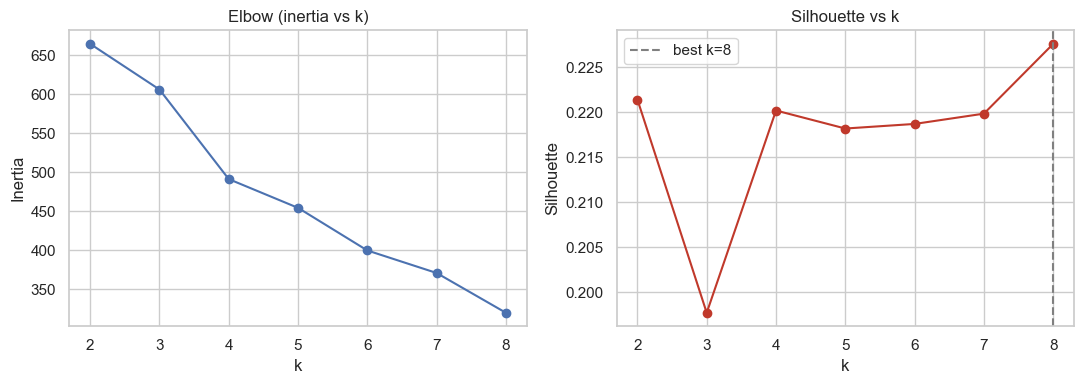

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(ks), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow (inertia vs k)")
axes[1].plot(list(ks), sil_scores, marker="o", color="#c0392b")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
axes[1].set_title("Silhouette vs k")
axes[1].axvline(best_k, color="gray", ls="--", label=f"best k={best_k}")
axes[1].legend()
plt.tight_layout()
plt.show()

## Step 5 — Fit KMeans with chosen K

In [8]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
airports_model["cluster"] = kmeans.fit_predict(X_scaled)
airports_model["cluster"].value_counts().sort_index()

cluster
0     8
1    19
2     6
3     5
4     8
5     7
6    16
7     3
Name: count, dtype: int64

## Step 6 — Cluster interpretation (size, profile, dominant cause, sample airports)

In [9]:
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
cent_df = pd.DataFrame(centroids_orig, columns=FEATURE_COLS)
cent_df.insert(0, "cluster", range(best_k))

share_cols = [
    "CarrierShare",
    "WeatherShare",
    "NASShare",
    "SecurityShare",
    "LateAircraftShare",
]
dominant = (
    cent_df[share_cols]
    .idxmax(axis=1)
    .str.replace("Share", "", regex=False)
    .str.strip()
)

rows = []
for c in range(best_k):
    sub = airports_model[airports_model["cluster"] == c]
    samples = sub.nlargest(5, "FlightsCount")["Origin"].tolist()
    rows.append({
        "cluster": c,
        "n_airports": len(sub),
        "dominant_delay_type": dominant.iloc[c],
        "sample_airports": ", ".join(samples),
    })

cluster_summary = pd.DataFrame(rows).merge(
    cent_df.add_prefix("centroid_").rename(columns={"centroid_cluster": "cluster"}),
    on="cluster",
    how="left",
)
cluster_summary



,cluster,n_airports,dominant_delay_type,sample_airports,centroid_DelayedFlightRate,centroid_AvgArrDelay,centroid_AvgCarrierDelay,centroid_AvgWeatherDelay,centroid_AvgNASDelay,centroid_AvgSecurityDelay,centroid_AvgLateAircraftDelay,centroid_CarrierShare,centroid_WeatherShare,centroid_NASShare,centroid_SecurityShare,centroid_LateAircraftShare
0,0,8,LateAircraft,"ORD, CLT, EWR, BOS, PHL",0.450767,7.834052,2.392066,0.443569,2.567262,0.018487,3.035499,0.281190,0.050752,0.304317,0.002218,0.361523
1,1,19,LateAircraft,"LGA, MCO, DCA, PIT, TPA",0.422885,5.581269,1.502956,0.273628,2.038157,0.003725,2.363810,0.242902,0.044338,0.330333,0.000591,0.381835
2,2,6,LateAircraft,"LAX, PHX, OAK, PDX, SJC",0.434101,4.529149,1.327493,0.072225,0.885561,0.018532,1.960861,0.304583,0.017066,0.206350,0.004368,0.467633
3,3,5,Carrier,"SLC, SEA, MEM, HNL, ANC",0.427848,3.912914,1.878544,0.148812,1.021759,0.005082,1.429785,0.426569,0.031608,0.220787,0.001107,0.319930
4,4,8,LateAircraft,"DEN, SFO, LAS, BWI, MDW",0.441564,6.657765,2.060999,0.238035,1.285931,0.011044,3.185767,0.304367,0.034744,0.187558,0.001676,0.471655
5,5,7,Carrier,"ATL, DFW, IAH, DTW, MSP",0.458308,6.880821,2.278430,0.498769,1.841695,0.007100,1.832016,0.353355,0.077398,0.288275,0.001095,0.279877
6,6,16,LateAircraft,"STL, SAN, BNA, MCI, MSY",0.413232,4.660166,1.124209,0.165851,1.178540,0.005905,2.246928,0.238957,0.034991,0.248573,0.001250,0.476230
7,7,3,LateAircraft,"BDL, PBI, PVD",0.414415,4.831356,1.196375,0.201720,2.192245,0.019267,2.298220,0.205225,0.036067,0.370719,0.003250,0.384740


## Step 7 — PCA (2D) for visualization

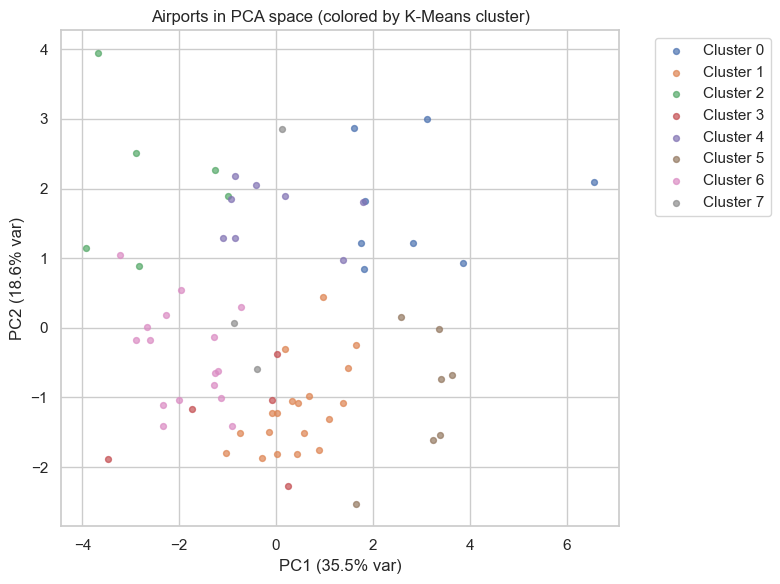

In [10]:
pca = PCA(n_components=2, random_state=42)
xy = pca.fit_transform(X_scaled)
airports_model["pc1"] = xy[:, 0]
airports_model["pc2"] = xy[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
for c in range(best_k):
    sub = airports_model[airports_model["cluster"] == c]
    ax.scatter(sub["pc1"], sub["pc2"], s=18, alpha=0.7, label=f"Cluster {c}")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("Airports in PCA space (colored by K-Means cluster)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Charts — Centroid comparison and cluster sizes

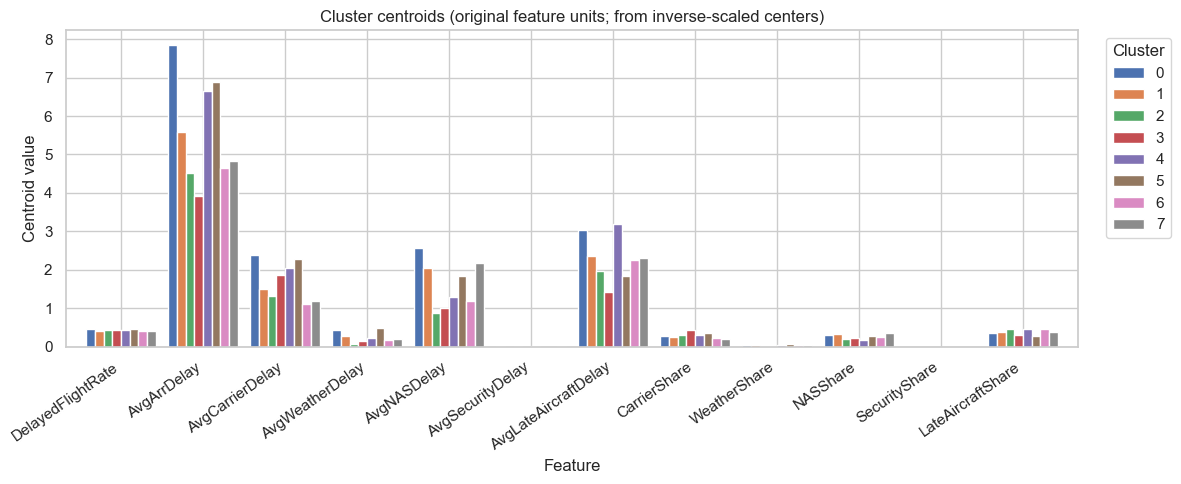

In [11]:
plot_cent = cent_df.set_index("cluster")[FEATURE_COLS]
fig, ax = plt.subplots(figsize=(12, 5))
plot_cent.T.plot(kind="bar", ax=ax, width=0.85)
ax.set_title("Cluster centroids (original feature units; from inverse-scaled centers)")
ax.set_xlabel("Feature")
ax.set_ylabel("Centroid value")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

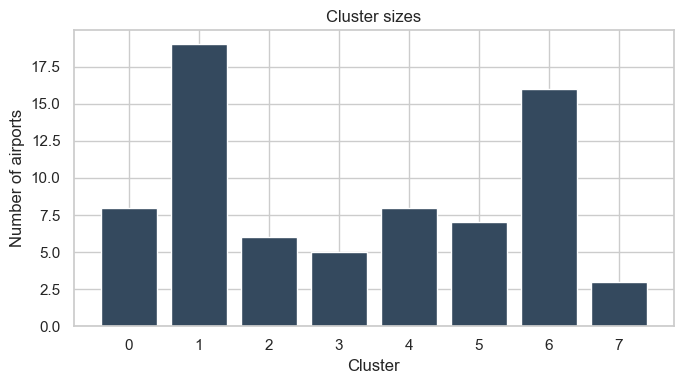

In [12]:
vc = airports_model["cluster"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(vc.index.astype(str), vc.values, color="#34495e")
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of airports")
ax.set_title("Cluster sizes")
plt.tight_layout()
plt.show()

In [13]:
rep_rows = []
for c in range(best_k):
    sub = airports_model[airports_model["cluster"] == c].nlargest(10, "FlightsCount")
    for _, r in sub.iterrows():
        rep_rows.append({"cluster": c, "Origin": r["Origin"], "FlightsCount": r["FlightsCount"]})
representative_airports = pd.DataFrame(rep_rows)
representative_airports

,cluster,Origin,FlightsCount
0,0,ORD,100208
1,0,CLT,42452
2,0,EWR,40510
3,0,BOS,36341
4,0,PHL,31712
5,0,JFK,25631
6,0,IAD,20400
7,0,FLL,18934
8,1,LGA,35590
9,1,MCO,34145


## Export CSVs

In [14]:
profiles_out = profiles.merge(
    airports_model[["Origin", "cluster", "pc1", "pc2"]],
    on="Origin",
    how="left",
)
profiles_out.to_csv("airport_delay_profiles.csv", index=False)

airport_clusters = airports_model[[
    "Origin",
    "FlightsCount",
    "DelayedFlightRate",
    "AvgArrDelay",
    "cluster",
    "pc1",
    "pc2",
]].copy()
airport_clusters.to_csv("airport_clusters.csv", index=False)

cluster_summary.to_csv("cluster_summary.csv", index=False)